In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

In [8]:
df = pd.read_csv("C:/Users/ASUS/Downloads/ecommerce_customer_dataset.csv")
df.head()

,CustomerID,Age,Gender,Region,MembershipType,AnnualIncome,PreferredCategory,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore,UsedDiscount,Churned
0,5001,46,Female,North,Gold,15000.00,Electronics,9,178.87,1623.66,1.0,Yes,No
1,5002,18,Male,West,Bronze,57636.40,Beauty,11,82.52,924.46,2.0,Yes,No
2,5003,29,Male,East,Silver,34712.51,NaN,4,125.91,526.91,1.0,Yes,No
3,5004,25,Other,West,Silver,42007.37,Beauty,5,87.31,393.02,5.0,Yes,No
4,5005,39,Male,Central,Gold,99919.96,Fashion,5,157.49,804.23,4.0,No,No


In [9]:
df.shape

(300, 13)

In [10]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Region', 'MembershipType',
       'AnnualIncome', 'PreferredCategory', 'PurchaseFrequency',
       'AvgOrderValue', 'TotalSpent', 'SatisfactionScore', 'UsedDiscount',
       'Churned'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         300 non-null    int64  
 1   Age                300 non-null    int64  
 2   Gender             300 non-null    object 
 3   Region             300 non-null    object 
 4   MembershipType     300 non-null    object 
 5   AnnualIncome       288 non-null    float64
 6   PreferredCategory  288 non-null    object 
 7   PurchaseFrequency  300 non-null    int64  
 8   AvgOrderValue      300 non-null    float64
 9   TotalSpent         300 non-null    float64
 10  SatisfactionScore  288 non-null    float64
 11  UsedDiscount       300 non-null    object 
 12  Churned            300 non-null    object 
dtypes: float64(4), int64(3), object(6)
memory usage: 30.6+ KB


In [6]:
df.isnull().sum()

CustomerID            0
Age                   0
Gender                0
Region                0
MembershipType        0
AnnualIncome         12
PreferredCategory    12
PurchaseFrequency     0
AvgOrderValue         0
TotalSpent            0
SatisfactionScore    12
UsedDiscount          0
Churned               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.describe()

,CustomerID,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore
count,300.000000,300.000000,288.000000,300.000000,300.000000,300.000000,288.000000
mean,5150.500000,32.693333,53635.930660,7.340000,86.006333,662.577133,2.909722
std,86.746758,9.663535,17820.217542,2.869118,44.213097,505.904366,1.391428
min,5001.000000,18.000000,15000.000000,1.000000,10.000000,9.020000,1.000000
25%,5075.750000,25.000000,41547.877500,5.000000,55.360000,349.767500,2.000000
50%,5150.500000,33.000000,52278.240000,7.000000,79.765000,533.200000,3.000000
75%,5225.250000,39.000000,64215.880000,9.000000,108.472500,804.700000,4.000000
max,5300.000000,67.000000,108437.290000,17.000000,261.990000,2860.410000,5.000000


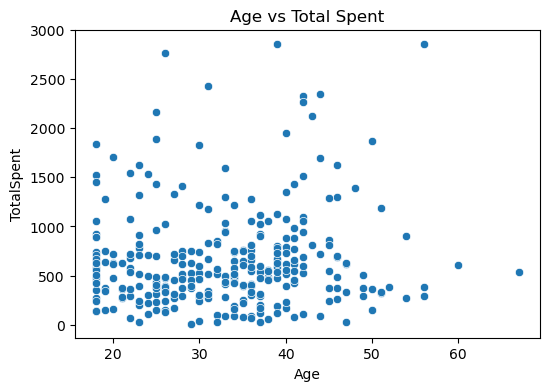

In [13]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="Age", y="TotalSpent", data=df)

plt.title("Age vs Total Spent")

plt.show()

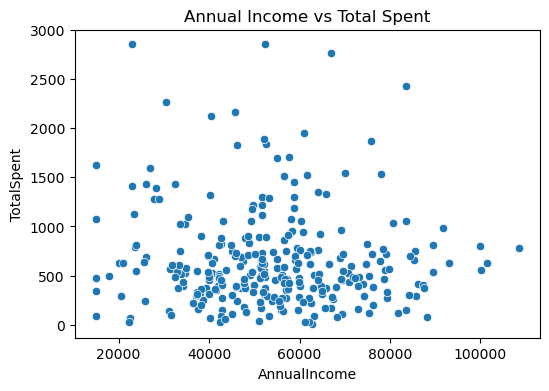

In [14]:
plt.figure(figsize=(6,4))

sns.scatterplot(x="AnnualIncome", y="TotalSpent", data=df)

plt.title("Annual Income vs Total Spent")

plt.show()

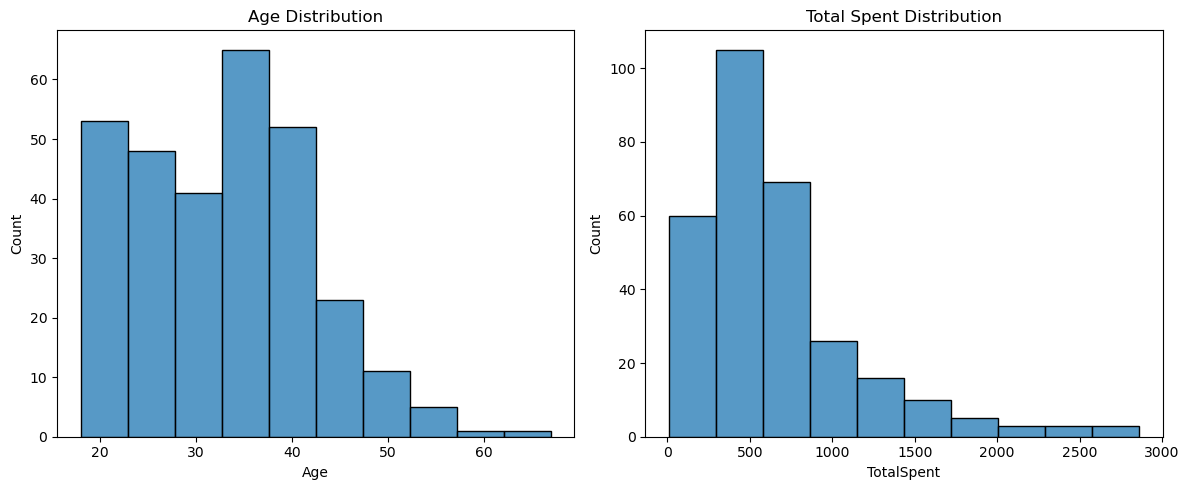

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(df["Age"], bins=10)

plt.title("Age Distribution")

plt.subplot(1,2,2)

sns.histplot(df["TotalSpent"], bins=10)

plt.title("Total Spent Distribution")

plt.tight_layout()

plt.show()

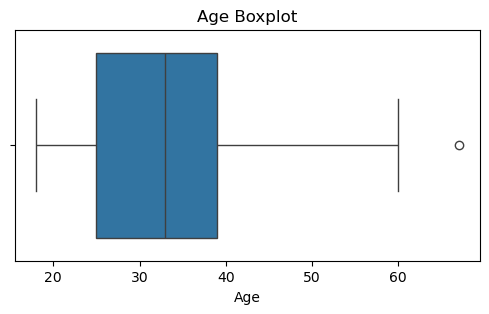

In [16]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["Age"])

plt.title("Age Boxplot")

plt.show()

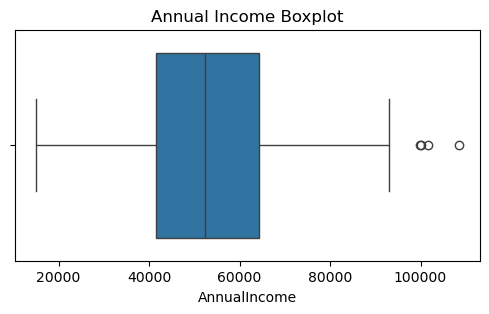

In [17]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["AnnualIncome"])

plt.title("Annual Income Boxplot")

plt.show()

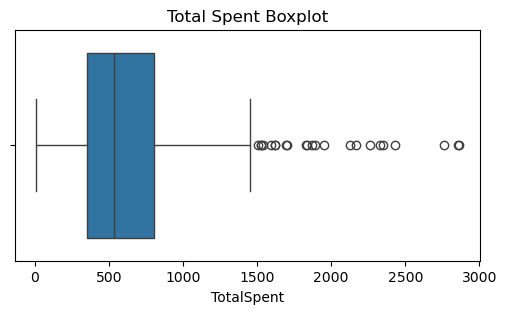

In [18]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["TotalSpent"])

plt.title("Total Spent Boxplot")

plt.show()

In [19]:
Q1 = df["TotalSpent"].quantile(0.25)

Q3 = df["TotalSpent"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print("Lower Limit :", lower)

print("Upper Limit :", upper)

Lower Limit : -332.6312500000001
Upper Limit : 1487.09875


In [20]:
outliers = df[(df["TotalSpent"] < lower) | (df["TotalSpent"] > upper)]
outliers

,CustomerID,Age,Gender,Region,MembershipType,AnnualIncome,PreferredCategory,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore,UsedDiscount,Churned
0,5001,46,Female,North,Gold,15000.00,Electronics,9,178.87,1623.66,1.0,Yes,No
32,5033,18,Male,South,Gold,61696.71,Fashion,11,135.51,1526.64,2.0,Yes,No
33,5034,42,Female,East,Gold,56624.89,Home & Kitchen,10,153.78,1508.80,2.0,No,No
43,5044,56,Female,South,Platinum,23080.97,Fashion,12,239.12,2860.41,5.0,No,No
47,5048,24,Male,Central,Gold,78111.05,Sports,10,150.74,1529.91,2.0,No,No
53,5054,50,Female,East,Platinum,75826.68,Beauty,12,158.14,1870.95,5.0,Yes,No
80,5081,18,Female,North,Silver,52575.29,Sports,13,142.49,1837.95,3.0,No,Yes
95,5096,43,Female,East,Platinum,40430.15,Electronics,14,145.65,2125.99,3.0,No,No
97,5098,42,Male,West,Platinum,NaN,Beauty,10,239.87,2326.94,2.0,Yes,No
113,5114,30,Other,West,Platinum,46129.90,Fashion,16,112.80,1827.54,5.0,No,No


In [21]:
df = df[(df["TotalSpent"] >= lower) & (df["TotalSpent"] <= upper)]
df.shape

(277, 13)


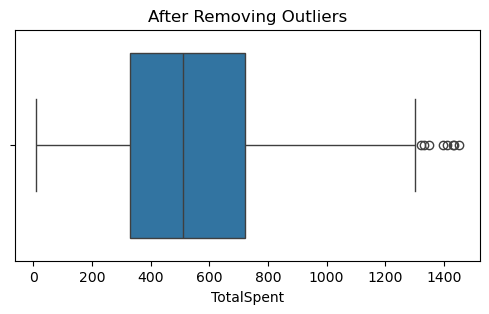

In [22]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["TotalSpent"])

plt.title("After Removing Outliers")

plt.show()

In [23]:
features = df[[
    "Age",
    "AnnualIncome",
    "PurchaseFrequency",
    "AvgOrderValue",
    "TotalSpent",
    "SatisfactionScore"
]]

features.head()

,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore
1,18,57636.40,11,82.52,924.46,2.0
2,29,34712.51,4,125.91,526.91,1.0
3,25,42007.37,5,87.31,393.02,5.0
4,39,99919.96,5,157.49,804.23,4.0
5,45,46256.72,4,34.27,236.83,5.0


In [24]:
features.corr()

,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore
Age,1.000000,0.034613,-0.046637,0.093373,0.037761,0.050215
AnnualIncome,0.034613,1.000000,-0.021127,-0.023869,-0.058338,0.001687
PurchaseFrequency,-0.046637,-0.021127,1.000000,0.024175,0.604847,-0.008104
AvgOrderValue,0.093373,-0.023869,0.024175,1.000000,0.751596,-0.065544
TotalSpent,0.037761,-0.058338,0.604847,0.751596,1.000000,-0.035761
SatisfactionScore,0.050215,0.001687,-0.008104,-0.065544,-0.035761,1.000000


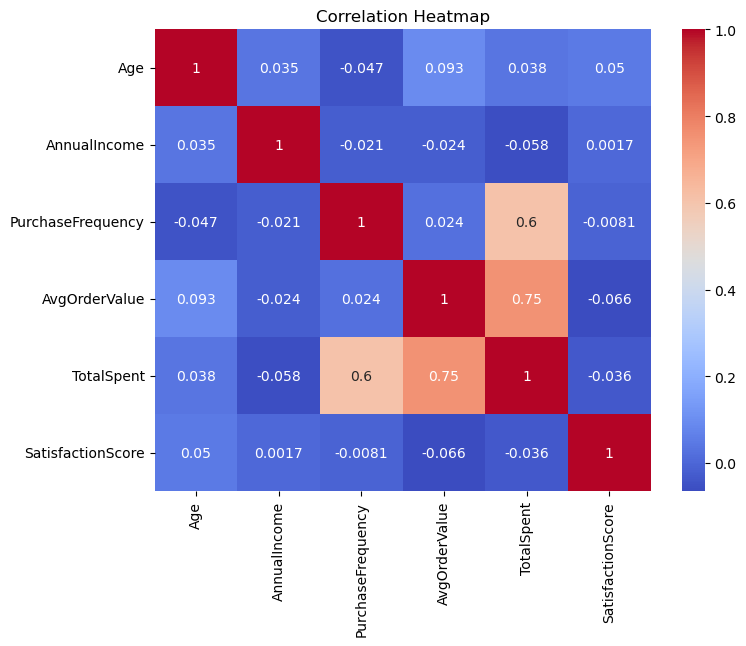

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(features.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [26]:
df.mean(numeric_only=True)

CustomerID            5151.083032
Age                     32.581227
AnnualIncome         53716.197425
PurchaseFrequency        7.018051
AvgOrderValue           78.054585
TotalSpent             552.031444
SatisfactionScore        2.920755
dtype: float64

In [27]:
df.median(numeric_only=True)

CustomerID            5151.00
Age                     33.00
AnnualIncome         52225.87
PurchaseFrequency        7.00
AvgOrderValue           76.34
TotalSpent             509.17
SatisfactionScore        3.00
dtype: float64

In [29]:
df.mode().iloc[0]

CustomerID                     5002
Age                            18.0
Gender                         Male
Region                        North
MembershipType               Bronze
AnnualIncome                15000.0
PreferredCategory    Home & Kitchen
PurchaseFrequency               7.0
AvgOrderValue                  10.0
TotalSpent                     9.02
SatisfactionScore               2.0
UsedDiscount                    Yes
Churned                          No
Name: 0, dtype: object

In [30]:
df.min(numeric_only=True)

CustomerID            5002.00
Age                     18.00
AnnualIncome         15000.00
PurchaseFrequency        1.00
AvgOrderValue           10.00
TotalSpent               9.02
SatisfactionScore        1.00
dtype: float64

In [31]:
df.max(numeric_only=True)

CustomerID             5300.00
Age                      67.00
AnnualIncome         108437.29
PurchaseFrequency        17.00
AvgOrderValue           181.45
TotalSpent             1450.62
SatisfactionScore         5.00
dtype: float64

In [32]:
df.std(numeric_only=True)

CustomerID              87.047361
Age                      9.542700
AnnualIncome         17799.960919
PurchaseFrequency        2.677679
AvgOrderValue           34.188538
TotalSpent             319.520007
SatisfactionScore        1.399859
dtype: float64

In [33]:
df.var(numeric_only=True)

CustomerID           7.577243e+03
Age                  9.106312e+01
AnnualIncome         3.168386e+08
PurchaseFrequency    7.169963e+00
AvgOrderValue        1.168856e+03
TotalSpent           1.020930e+05
SatisfactionScore    1.959605e+00
dtype: float64

In [34]:
df.describe()

,CustomerID,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore
count,277.000000,277.000000,268.000000,277.000000,277.000000,277.000000,265.000000
mean,5151.083032,32.581227,53716.197425,7.018051,78.054585,552.031444,2.920755
std,87.047361,9.542700,17799.960919,2.677679,34.188538,319.520007,1.399859
min,5002.000000,18.000000,15000.000000,1.000000,10.000000,9.020000,1.000000
25%,5076.000000,25.000000,41547.877500,5.000000,52.460000,328.580000,2.000000
50%,5151.000000,33.000000,52225.870000,7.000000,76.340000,509.170000,3.000000
75%,5227.000000,39.000000,64215.880000,8.000000,99.500000,722.800000,4.000000
max,5300.000000,67.000000,108437.290000,17.000000,181.450000,1450.620000,5.000000


In [35]:
import pandas as pd
from scipy.stats import ttest_ind

In [36]:
df = pd.read_csv("C:/Users/ASUS/Downloads/ecommerce_customer_dataset.csv")

In [37]:
discount = df[df["UsedDiscount"] == "Yes"]["TotalSpent"]

no_discount = df[df["UsedDiscount"] == "No"]["TotalSpent"]

In [38]:
t_stat, p_value = ttest_ind(discount, no_discount, nan_policy="omit")

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -1.4283761026475121
P-Value: 0.15423086589325957


In [39]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
le = LabelEncoder()

In [42]:
df.select_dtypes(include="object").columns

Index(['Gender', 'Region', 'MembershipType', 'PreferredCategory',
       'UsedDiscount', 'Churned'],
      dtype='object')

In [43]:
df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,CustomerID,Age,Gender,Region,MembershipType,AnnualIncome,PreferredCategory,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore,UsedDiscount,Churned
0,5001,46,0,North,Gold,15000.00,Electronics,9,178.87,1623.66,1.0,Yes,No
1,5002,18,1,West,Bronze,57636.40,Beauty,11,82.52,924.46,2.0,Yes,No
2,5003,29,1,East,Silver,34712.51,NaN,4,125.91,526.91,1.0,Yes,No
3,5004,25,2,West,Silver,42007.37,Beauty,5,87.31,393.02,5.0,Yes,No
4,5005,39,1,Central,Gold,99919.96,Fashion,5,157.49,804.23,4.0,No,No


In [44]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [45]:
df.head()

,CustomerID,Age,Gender,Region,MembershipType,AnnualIncome,PreferredCategory,PurchaseFrequency,AvgOrderValue,TotalSpent,SatisfactionScore,UsedDiscount,Churned
0,5001,46,0,2,1,15000.00,1,9,178.87,1623.66,1.0,1,0
1,5002,18,1,4,0,57636.40,0,11,82.52,924.46,2.0,1,0
2,5003,29,1,1,3,34712.51,5,4,125.91,526.91,1.0,1,0
3,5004,25,2,4,3,42007.37,0,5,87.31,393.02,5.0,1,0
4,5005,39,1,0,1,99919.96,2,5,157.49,804.23,4.0,0,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         300 non-null    int64  
 1   Age                300 non-null    int64  
 2   Gender             300 non-null    int64  
 3   Region             300 non-null    int64  
 4   MembershipType     300 non-null    int64  
 5   AnnualIncome       288 non-null    float64
 6   PreferredCategory  300 non-null    int64  
 7   PurchaseFrequency  300 non-null    int64  
 8   AvgOrderValue      300 non-null    float64
 9   TotalSpent         300 non-null    float64
 10  SatisfactionScore  288 non-null    float64
 11  UsedDiscount       300 non-null    int64  
 12  Churned            300 non-null    int64  
dtypes: float64(4), int64(9)
memory usage: 30.6 KB
